In [2]:
import scipy

scipy.stats.distributions.poisson.pmf(5, 4.5)

0.17082685848611215

# 1/10   Введение

## Задание 1.10

В интернет-магазине среднее время между покупками одного пользователя составляет $5$ дней. Если пользователь не сделал покупку за первые $7$ дней, какова вероятность того, что он сделает покупку в течение последующих $3$ дней? Ответ округлите до трех знаков после разделителя.

In [3]:
import math

def get_factorial(number):
    if number <= 1:
        return 1
    else:
        return get_factorial(number - 1) * number

In [4]:
lambda_value = 1 / 5
days = 3
p_days = lambda_value ** days / get_factorial(days) * math.exp(-lambda_value)
1 - p_days

0.998908358995896

In [5]:
import math

# Параметры
mean_time = 5  # среднее время между покупками в днях
lambda_param = 1 / mean_time  # параметр экспоненциального распределения

# Время, за которое нужно найти вероятность (после 7 дней без покупок)
t = 3

# Вероятность P(T <= 3) для экспоненциального распределения
probability = 1 - math.exp(-lambda_param * t)

print(f"Среднее время между покупками: {mean_time} дней")
print(f"Параметр λ: {lambda_param:.3f}")
print(f"Вероятность покупки в течение {t} дней: {probability:.6f}")
print(f"Ответ (округлено до 3 знаков): {probability:.3f}")

Среднее время между покупками: 5 дней
Параметр λ: 0.200
Вероятность покупки в течение 3 дней: 0.451188
Ответ (округлено до 3 знаков): 0.451


In [6]:
# Альтернативная версия с использованием scipy
from scipy.stats import expon

# Параметры (в scipy scale = 1/λ = mean)
probability_scipy = expon.cdf(t, scale=mean_time)

print(f"Проверка через scipy: {probability_scipy:.6f}")
print(f"Округлённый ответ: {probability_scipy:.3f}")

Проверка через scipy: 0.451188
Округлённый ответ: 0.451


# 3/10   Основные распределения случайных величин

## Дискретное равномерное распределение

$M\xi = \frac{a_1 + a_2 + … + a_n}{n}\Leftrightarrow \frac{n+1}{2}$

$D\xi = \frac{(a_1 - M\xi)^2 + \dots + (a_n - M\xi)^2}{n}\Leftrightarrow \frac{n^2-1}{12}$

## Ширина пика на половине высоты (FWHM)

В случае нормального распределения, определяемого выражением:

$f(x) = \frac{1}{\sigma \sqrt{2 \pi} } \exp \left[ -\frac{(x-x_0)^2}{2 \sigma^2} \right]\,$

где $\sigma$ — стандартное отклонение, $x_0$ — медиана, высота максимума равна $\frac{1}{\sigma \sqrt{2 \pi} },$ а полуширина выражается через стандартное отклонение следующим образом:

$\mathrm{FWHM} =   2 \sqrt{2 \ln 2 } \; \sigma \approx 2{,}355 \; \sigma$.

(array([0.11984801, 0.23969601, 0.31160482, 0.67114884, 0.93481446,
        1.39023688, 1.51008489, 2.13329453, 2.27711214, 2.51680815,
        2.25314254, 2.08535533, 1.89359852, 1.41420649, 1.27038888,
        0.69511844, 0.64717924, 0.50336163, 0.26366562, 0.43145283,
        0.16778721, 0.09587841, 0.0239696 , 0.0479392 , 0.0479392 ,
        0.        , 0.        , 0.        , 0.        , 0.0239696 ]),
 array([0.56340961, 0.60512912, 0.64684863, 0.68856814, 0.73028765,
        0.77200716, 0.81372666, 0.85544617, 0.89716568, 0.93888519,
        0.9806047 , 1.02232421, 1.06404372, 1.10576323, 1.14748274,
        1.18920224, 1.23092175, 1.27264126, 1.31436077, 1.35608028,
        1.39779979, 1.4395193 , 1.48123881, 1.52295831, 1.56467782,
        1.60639733, 1.64811684, 1.68983635, 1.73155586, 1.77327537,
        1.81499488]),
 <BarContainer object of 30 artists>)

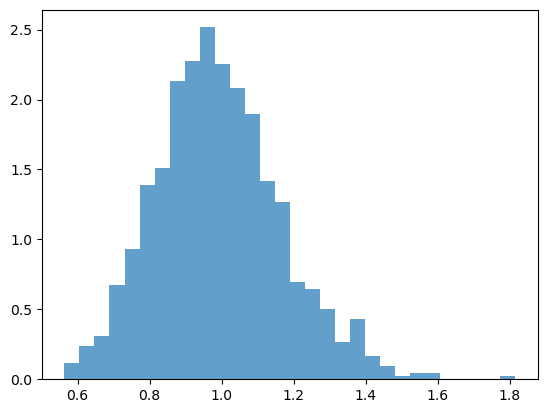

In [7]:
# Пример: Эмпирическая проверка ЦПТ
import numpy as np
import matplotlib.pyplot as plt
means = [np.mean(np.random.exponential(scale=1.0, size=30)) for _ in range(1000)]
plt.hist(means, bins=30, density=True, alpha=0.7)
# Наложить нормальную кривую с параметрами, предсказанными ЦПТ

In [8]:
import numpy as np
from scipy.stats import norm

# Параметры распределения
mu = 4
sigma = 1
threshold = 4.5

# Z-оценка
z = (threshold - mu) / sigma

# Вероятность P(Z > z)
prob = 1 - norm.cdf(z)

# Процент студентов
percent = prob * 100

# Округление до двух знаков после запятой
percent_rounded = round(percent, 2)

print(f"Z-оценка для балла {threshold}: {z:.2f}")
print(f"Вероятность балла > {threshold}: {prob:.5f}")
print(f"Процент студентов с баллом > {threshold}: {percent_rounded:.2f}%")

Z-оценка для балла 4.5: 0.50
Вероятность балла > 4.5: 0.30854
Процент студентов с баллом > 4.5: 30.85%


Точная P(S ≤ 35) = 0.8839
Приближенная P(S ≤ 35) = 0.0480
Ошибка: 0.8359


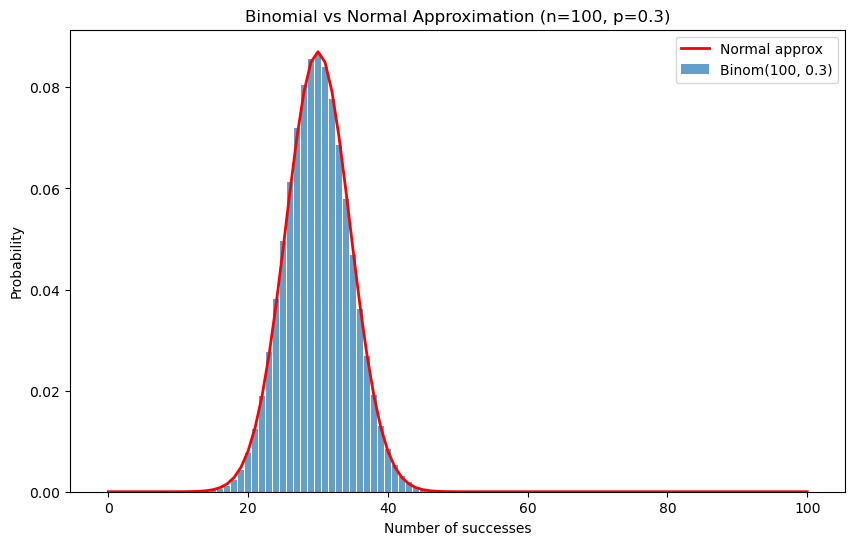

In [1]:
import numpy as np
from scipy.stats import norm, binom
import matplotlib.pyplot as plt

# Параметры
n = 100
p = 0.3
k_values = np.arange(0, n+1)

# Точное биномиальное распределение
exact_probs = binom.pmf(k_values, n, p)

# Нормальное приближение (без поправки)
mu = n * p
sigma = np.sqrt(n * p * (1 - p))
normal_approx = norm.pdf(k_values, mu, sigma)

# С поправкой на непрерывность (для кумулятивных вероятностей)
k = 35
exact_cdf = binom.cdf(k, n, p)
approx_cdf = norm.cdf(k + 0.5, mu, sigma) - norm.cdf(k - 0.5, mu, sigma)

print(f"Точная P(S ≤ {k}) = {exact_cdf:.4f}")
print(f"Приближенная P(S ≤ {k}) = {approx_cdf:.4f}")
print(f"Ошибка: {abs(exact_cdf - approx_cdf):.4f}")

# Визуализация
plt.figure(figsize=(10, 6))
plt.bar(k_values, exact_probs, alpha=0.7, label=f'Binom({n}, {p})', width=0.8)
plt.plot(k_values, normal_approx, 'r-', linewidth=2, label='Normal approx')
plt.xlabel('Number of successes')
plt.ylabel('Probability')
plt.legend()
plt.title(f'Binomial vs Normal Approximation (n={n}, p={p})')
plt.show()

# 5/10 основные понятия

In [1]:
import numpy as np
from scipy import stats

# Вычисление моментов для набора данных
data = np.random.normal(0, 1, 1000)

mean = np.mean(data)           # a1
variance = np.var(data)        # m2 (смещенная)
skewness = stats.skew(data)    # g1
kurtosis = stats.kurtosis(data)# g2

In [14]:
import numpy as np

# Выборка
sample = [1.5, 1.7, 2.1, 2.1, 3.0]
sample = [1.5, 2, 2.5]
sample = [-2, -1,-1,0,0,1,1,2,3,3,]
x = np.array(sample)

n = len(x)

# 1. Начальные моменты
a1 = np.mean(x)
a2 = np.mean(x**2)
a3 = np.mean(x**3)

# 2. Центральные моменты
m2 = np.mean((x - a1)**2)
m3 = np.mean((x - a1)**3)
m4 = np.mean((x - a1)**4)

# 3. Коэффициенты
s = np.sqrt(m2)
skew = m3 / (s**3)
kurt = m4 / (s**4) - 3

print(f"Среднее: {a1:.2f}")
print(f"Дисперсия: {m2:.3f}")
print(f"Асимметрия: {skew:.3f}")
print(f"Эксцесс: {kurt:.3f}")

Среднее: 0.60
Дисперсия: 2.640
Асимметрия: 0.101
Эксцесс: -1.145


In [13]:
# Несмещённая оценка дисперсии (исправленная выборочная дисперсия)
# ddof=1 означает деление на (n - 1)
var_est = np.var(sample, ddof=1)  # ddof = degrees of freedom
print(f"Несмещённая оценка Dξ: {var_est:.3f}")

Несмещённая оценка Dξ: 2.933


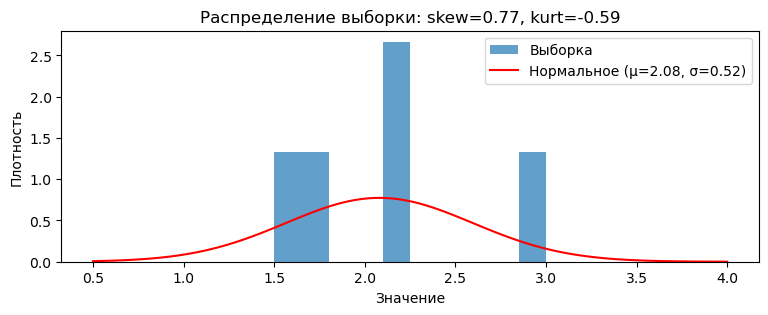

In [5]:
import matplotlib.pyplot as plt
from scipy.stats import norm

# Сравнение с нормальным распределением
x_range = np.linspace(min(x)-1, max(x)+1, 100)
pdf_norm = norm.pdf(x_range, a1, s)

plt.figure(figsize=(9, 3))
plt.hist(x, bins=10, density=True, alpha=0.7, label='Выборка')
plt.plot(x_range, pdf_norm, 'r-', label=f'Нормальное (μ={a1:.2f}, σ={s:.2f})')
plt.xlabel('Значение')
plt.ylabel('Плотность')
plt.title(f'Распределение выборки: skew={skew:.2f}, kurt={kurt:.2f}')
plt.legend()
plt.show()

In [8]:
import pandas as pd
sample = pd.DataFrame([ 1.0 , 2.5 , 3.0 , 4.5 ])
sample.describe()

,0
count,4.000000
mean,2.750000
std,1.443376
min,1.000000
25%,2.125000
50%,2.750000
75%,3.375000
max,4.500000


# программные инструменты

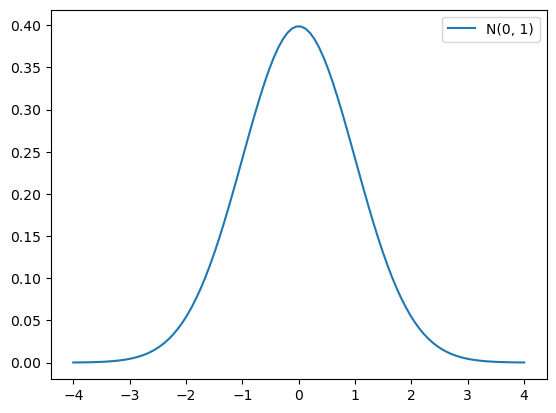

In [15]:
from scipy.stats import norm         # для работы с нормальным распределением
import numpy as np                      # для создания массива чисел
import matplotlib.pyplot as plt       # для построения графиков

x = np.linspace(-4, 4, 100)            # Генерирует 100 точек в диапазоне от −4 до 4.
pdf = norm.pdf(x, loc=0, scale=1) # вычисление плотности вероятности
plt.plot(x, pdf, label="N(0, 1)")      # рисует кривую
plt.legend()                                   # добавляет легенду
plt.show()                                     # отображает график

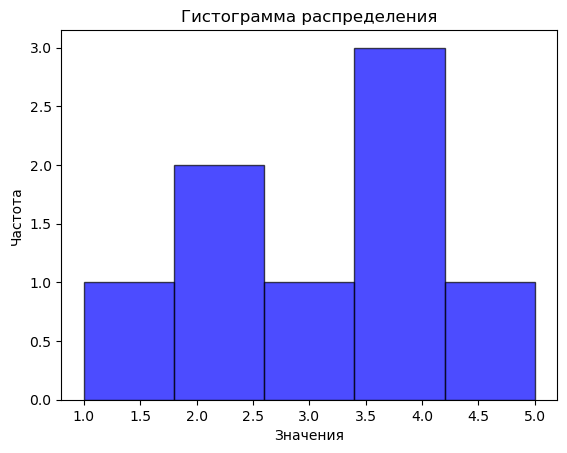

In [18]:
# Пример кода для построения гистограммы с использованием Matplotlib:

import matplotlib.pyplot as plt     # импортируем библиотеку
data = [1, 2, 2, 3, 4, 4, 4, 5]     # определяем массив данных
plt.hist(data, bins=5, alpha=0.7, color='blue', edgecolor='black') # рисуем гистограмму с 5 бинами, прозрачность столбцов 0.7, цвет заливки синий и границ - черный
plt.title("Гистограмма распределения") # название графика

#подписи осей
plt.xlabel("Значения")
plt.ylabel("Частота")
plt.show()

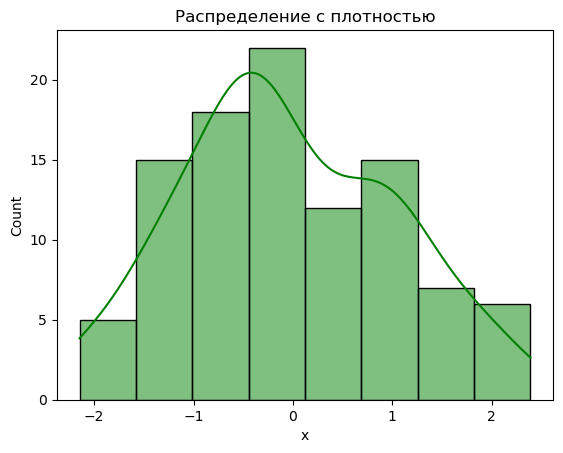

In [19]:
import seaborn as sns # импорт библиотек
import pandas as pd
#создаем датафрейм из 100 случайных чисел, взятых из стандартного нормального распределения
data = pd.DataFrame({'x': np.random.normal(size=100)})
#Построение гистограммы с KDE (Kernel Density Estimation) — гладкую кривую плотности.
sns.histplot(data['x'], kde=True, color='green')
plt.title("Распределение с плотностью")
plt.show()

Рассмотрим пример построения графиков PMF с использованием языка программирования Python


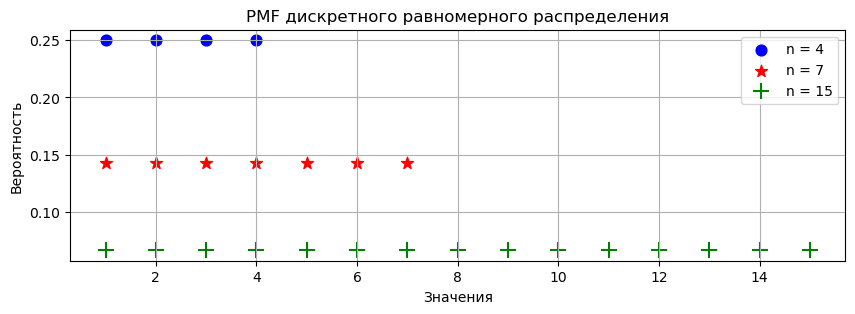

In [23]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазоны значений
x1 = np.arange(1, 5)                    	# Значения для n = 4
x2 = np.arange(1, 8)                    	# Значения для n = 7
x3 = np.arange(1, 16)                   	# Значения для n = 15

# Строим графики PMF
plt.scatter(x1, randint.pmf(x1, 1, 5), s=60, c="blue", marker="o", label='n = 4')
plt.scatter(x2, randint.pmf(x2, 1, 8), s=80, c="red", marker="*", label='n = 7')
plt.scatter(x3, randint.pmf(x3, 1, 16), s=120, c="green", marker="+", label='n = 15')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

Функция CDF для дискретного равномерного распределения реализуется на Python следующим образом



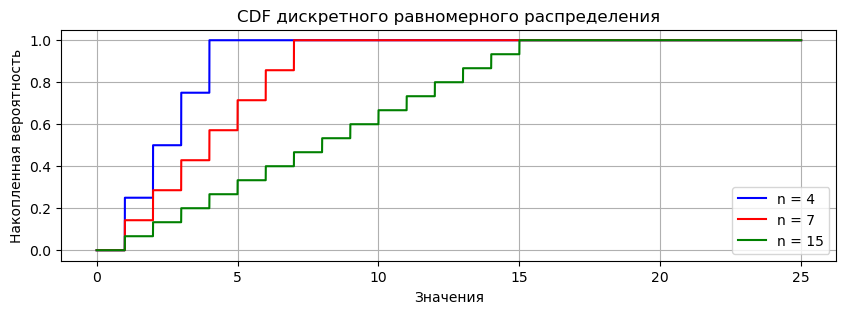

In [22]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import randint         	# Импортируем метод randint
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазоны значений
x = np.arange(0, 25, 0.001)             	# Создаем массив чисел от 0 до 25 с шагом 0.001

# Строим графики CDF
plt.plot(x, randint.cdf(x, 1, 5), c="blue", label='n = 4')   # CDF для n = 4
plt.plot(x, randint.cdf(x, 1, 8), c="red", label='n = 7')	# CDF для n = 7
plt.plot(x, randint.cdf(x, 1, 16), c="green", label='n = 15') # CDF для n = 15

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF дискретного равномерного распределения")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()


Посмотрим, как графически показать PMF и CDF распределения Бернулли в Python.

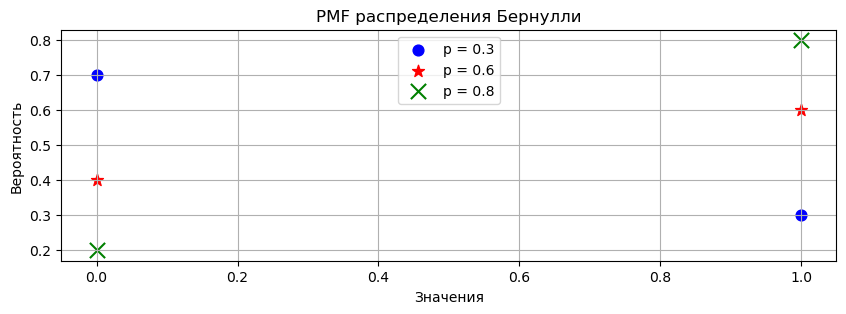

In [24]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазон значений
x = np.arange(0, 2)                     	# Значения 0 и 1

# Строим графики PMF
plt.scatter(x, bernoulli.pmf(x, 0.3), s=60, c="blue", marker="o", label='p = 0.3')
plt.scatter(x, bernoulli.pmf(x, 0.6), s=80, c="red", marker="*", label='p = 0.6')
plt.scatter(x, bernoulli.pmf(x, 0.8), s=120, c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper center')

# Отображаем график
plt.title("PMF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Вероятность")
plt.show()

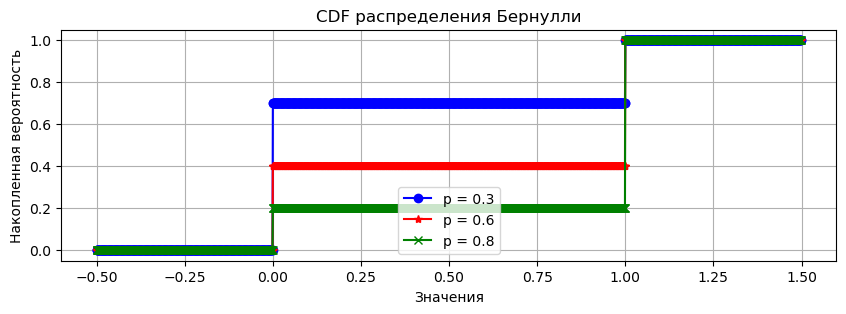

In [26]:
import numpy as np                      	# Импортируем библиотеку numpy
from scipy.stats import bernoulli       	# Импортируем метод bernoulli
import matplotlib.pyplot as plt         	# Импортируем библиотеку matplotlib

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем диапазон значений
x = np.arange(-0.5, 1.5, 0.001)

# Строим графики CDF
plt.plot(x, bernoulli.cdf(x, 0.3), c="blue", marker="o", label='p = 0.3')
plt.plot(x, bernoulli.cdf(x, 0.6), c="red", marker="*", label='p = 0.6')
plt.plot(x, bernoulli.cdf(x, 0.8), c="green", marker="x", label='p = 0.8')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower center')

# Отображаем график
plt.title("CDF распределения Бернулли")
plt.xlabel("Значения")
plt.ylabel("Накопленная вероятность")
plt.show()

Посмотрим, как графически показать PMF и CDF биномиального распределения в Python.

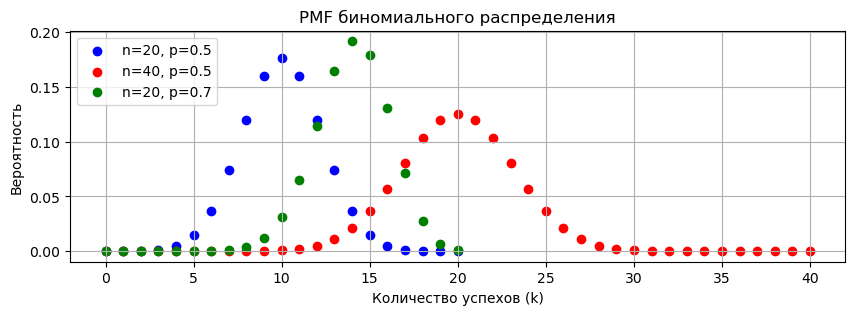

In [28]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 1)
plt.scatter(x, binom.pmf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("PMF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:

$F(X \le k) = \sum_{i=0}^k P(X = i)$

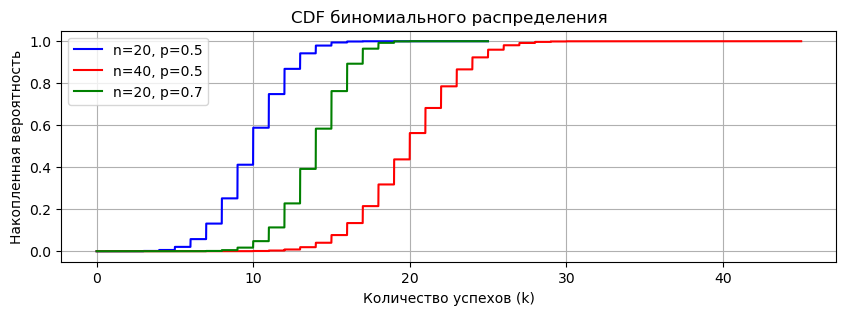

In [29]:
import numpy as np
from scipy.stats import binom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 20, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='b', label='n=20, p=0.5')

n, p = 40, 0.5
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='r', label='n=40, p=0.5')

n, p = 20, 0.7
x = np.arange(0, n + 5, 0.01)
plt.plot(x, binom.cdf(x, n, p), c='g', label='n=20, p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper left')

# Отображаем график
plt.title("CDF биномиального распределения")
plt.xlabel("Количество успехов (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

**Геометрическое распределение**

Посмотрим, как графически показать PMF и CDF геометрического распределения в Python. Функция PMF геометрического распределения показывает вероятность того, что первый успех произойдет на $k$-м испытании:

$P(X = k) = (1-p)^{k-1} p$

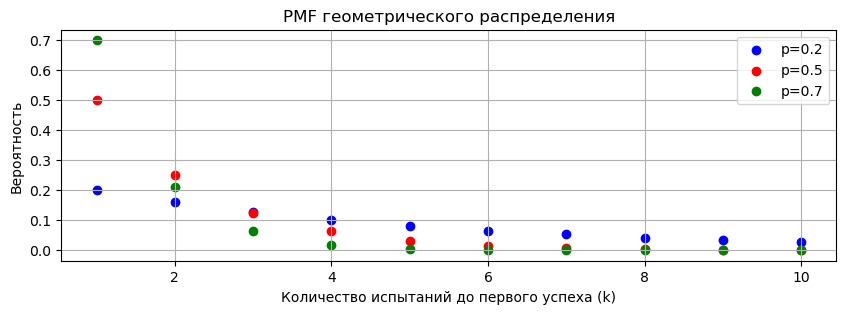

In [31]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
p = 0.2
x = np.arange(1, 11)  # Значения от 1 до 10
plt.scatter(x, geom.pmf(x, p), c='b', label='p=0.2')

p = 0.5
plt.scatter(x, geom.pmf(x, p), c='r', label='p=0.5')

p = 0.7
plt.scatter(x, geom.pmf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Вероятность")
plt.show()

Функция CDF показывает накопленную вероятность для значений $k$:

$F(X\le k ) = 1 − (1-p)^{⌊k⌋}, k \geq 1.$

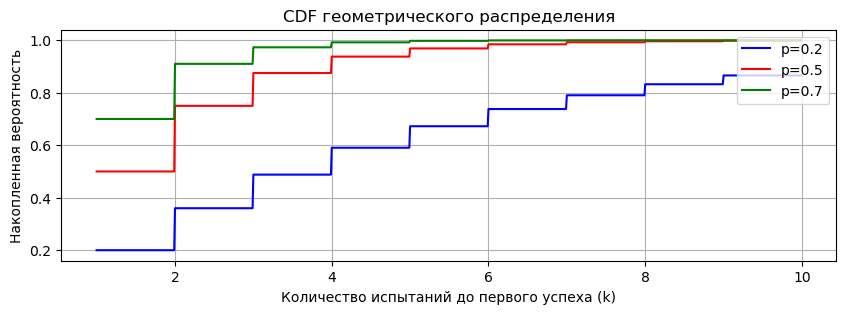

In [32]:
import numpy as np
from scipy.stats import geom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
p = 0.2
x = np.arange(1, 10, 0.01)
plt.plot(x, geom.cdf(x, p), c='b', label='p=0.2')

p = 0.5
plt.plot(x, geom.cdf(x, p), c='r', label='p=0.5')

p = 0.7
plt.plot(x, geom.cdf(x, p), c='g', label='p=0.7')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("CDF геометрического распределения")
plt.xlabel("Количество испытаний до первого успеха (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

Геометрическое распределение также является частным случаем отрицательного биномиального распределения.

**Отрицательное биномиальное распределение**

Отрицательное биномиальное распределение — это дискретное распределение вероятностей, которое моделирует количество неудач в последовательности независимых и идентично распределённых испытаний Бернулли до того, как произойдёт заданное (неслучайное) количество успехов (обозначается $r$).

Распределение Паскаля и распределение Поля́ являются частными случаями отрицательного биномиального распределения. Среди инженеров, климатологов и других специалистов принято использовать «Паскаля» для случая целочисленного параметра времени остановки $r$ и использовать «Поля́» для вещественного случая. Чаще используется «Паскаль».

Функция PMF отрицательного биномиального распределения показывает вероятность получения $r$ неудач до $k$-го успеха:

$P(X=k)= \begin{pmatrix} k+r-1 \\ k \end{pmatrix} \cdot p^r \cdot q^k$, где $\begin{pmatrix} k+r-1 \\ k \end{pmatrix}$  — биномиальный коэффициент.



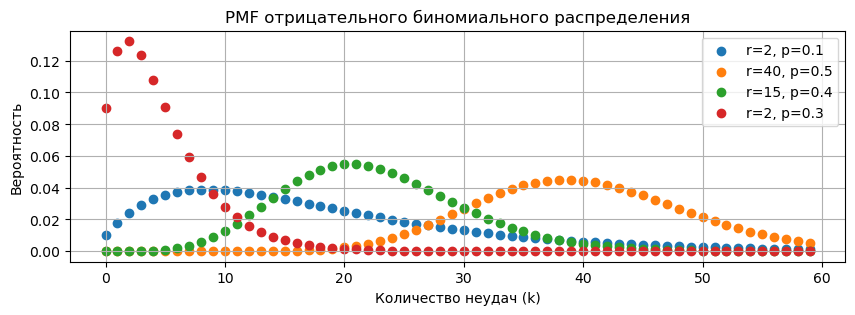

In [33]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 1)
plt.scatter(x, nbinom.pmf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='upper right')

# Отображаем график
plt.title("PMF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Вероятность")
plt.show()


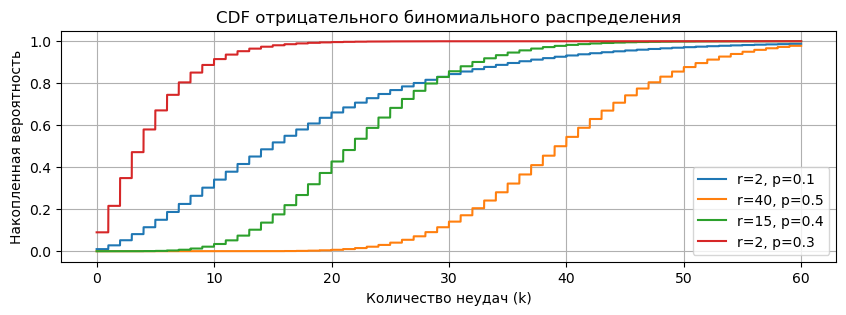

In [34]:
import numpy as np
from scipy.stats import nbinom
import matplotlib.pyplot as plt

# Создаем поле для графика
plt.figure(figsize=(10, 3))

# Определяем параметры
n, p = 2, 0.1
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.1')

n, p = 40, 0.5
x = np.arange(0, n * 1.5, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=40, p=0.5')

n, p = 15, 0.4
x = np.arange(0, n * 4, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=15, p=0.4')

n, p = 2, 0.3
x = np.arange(0, n * 30, 0.01)
plt.plot(x, nbinom.cdf(x, n, p), label='r=2, p=0.3')

# Добавляем сетку и легенду
plt.grid()
plt.legend(loc='lower right')

# Отображаем график
plt.title("CDF отрицательного биномиального распределения")
plt.xlabel("Количество неудач (k)")
plt.ylabel("Накопленная вероятность")
plt.show()

**Гипергеометрическое распределение**

Пусть общая совокупность содержит $N$ объектов, из них $D$ помечены как «$1$», а $N-D$ как «$0$». Будем считать выбор объекта с меткой «$1$», как успех, а с меткой «$0$» как неудачу. Проведём $n$ испытаний, причём выбранные объекты больше не будут участвовать в дальнейших испытаниях (без возвращения). Вероятность наступления $k$ успехов будет подчиняться гипергеометрическому распределению.